Mounted at /content/drive

🔹 Raw Dataset Overview (row level):
                                       transactionId  country  \
0  1de7f5dc96dbc27d11144d8139eef353deb8c6f1b4114e...   Norway   
1  2bde3a26600e85270a8cf054d107d20b78ad22d72bf52d...  Finland   
2  eb853f2666ec8daf13a9350c05cfd7d942c8eba4c3b81b...  Finland   
3  1de7f5dc96dbc27d11144d8139eef353deb8c6f1b4114e...   Norway   
4  98cc06ca94a79768306516555eb8dfa4015ae8a133e598...   France   

                                             EVModel  year  month  quarter  \
0  Audi Q4 e-tron, Skoda Enyaq iV, Volkswagen ID....  2024      5        2   
1  Audi Q4 e-tron, Skoda Enyaq iV, Volkswagen ID....  2025      3        1   
2                                      Tesla Model S  2024      7        3   
3  Audi Q4 e-tron, Skoda Enyaq iV, Volkswagen ID....  2024      5        2   
4                                      Tesla Model S  2025      3        1   

    soc  tempC  sampleTime10sIncrement    weekday  avgPowerW  avgCurrentA  \


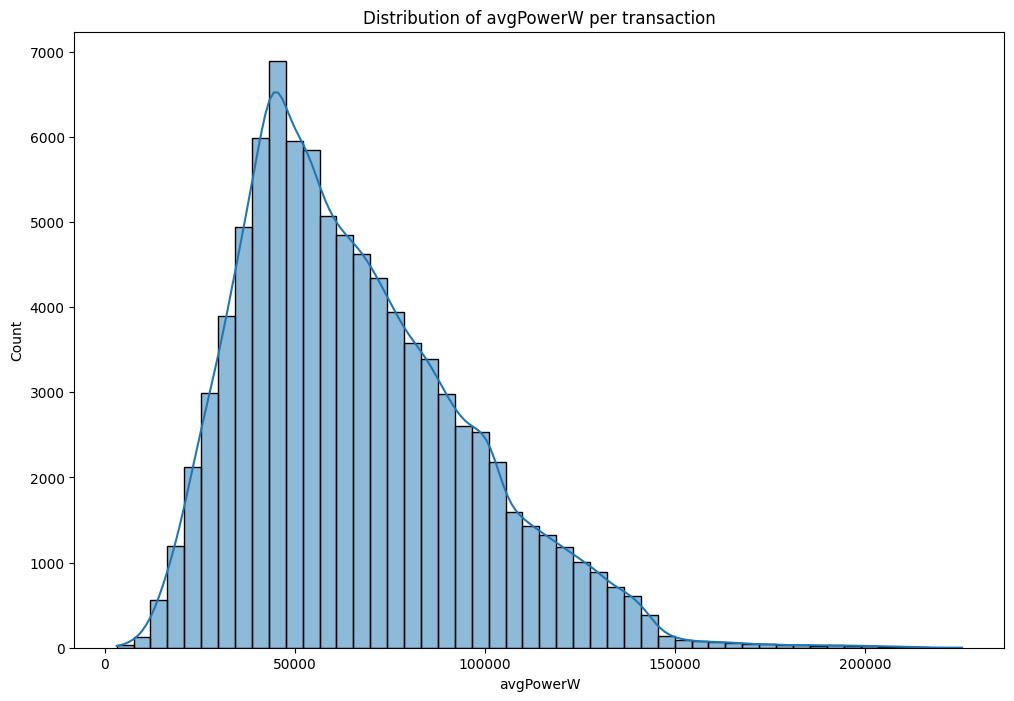

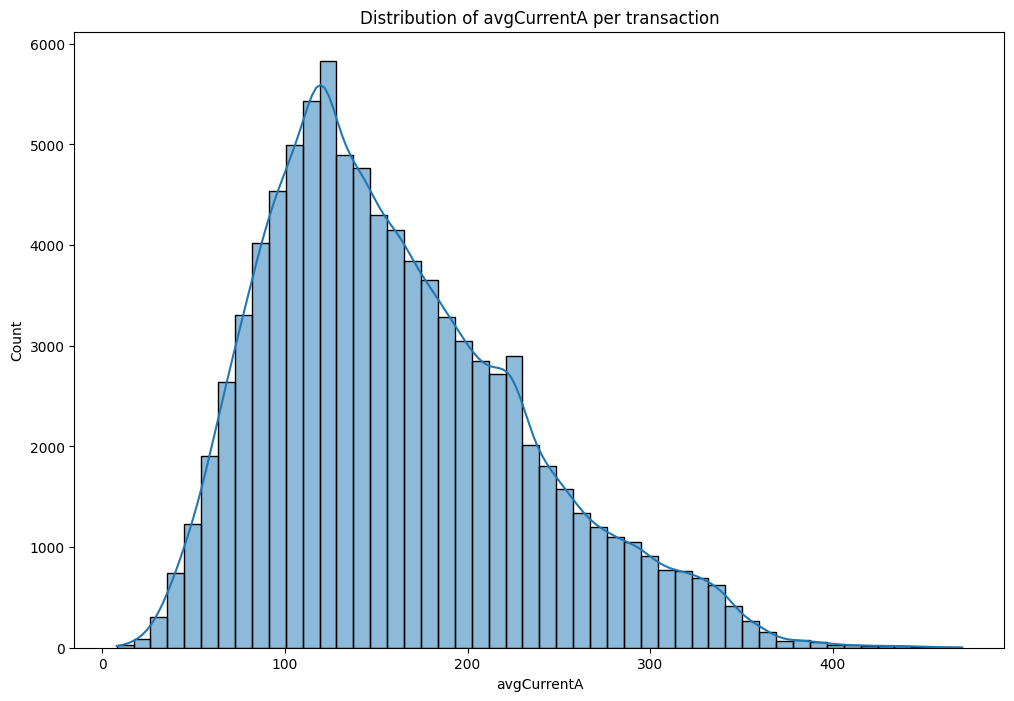

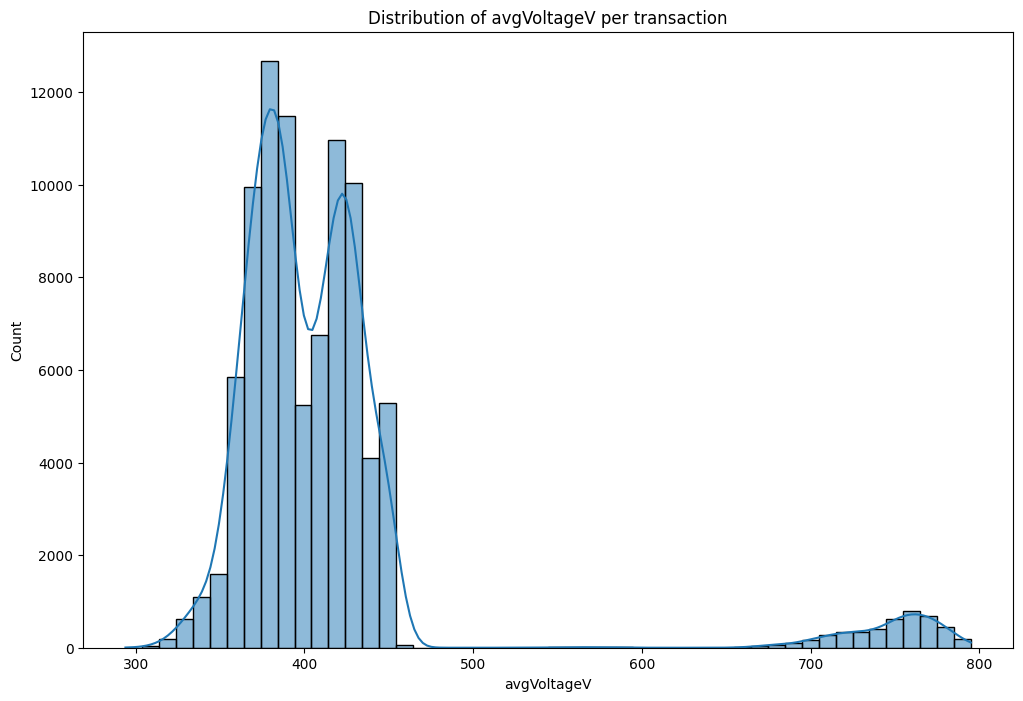

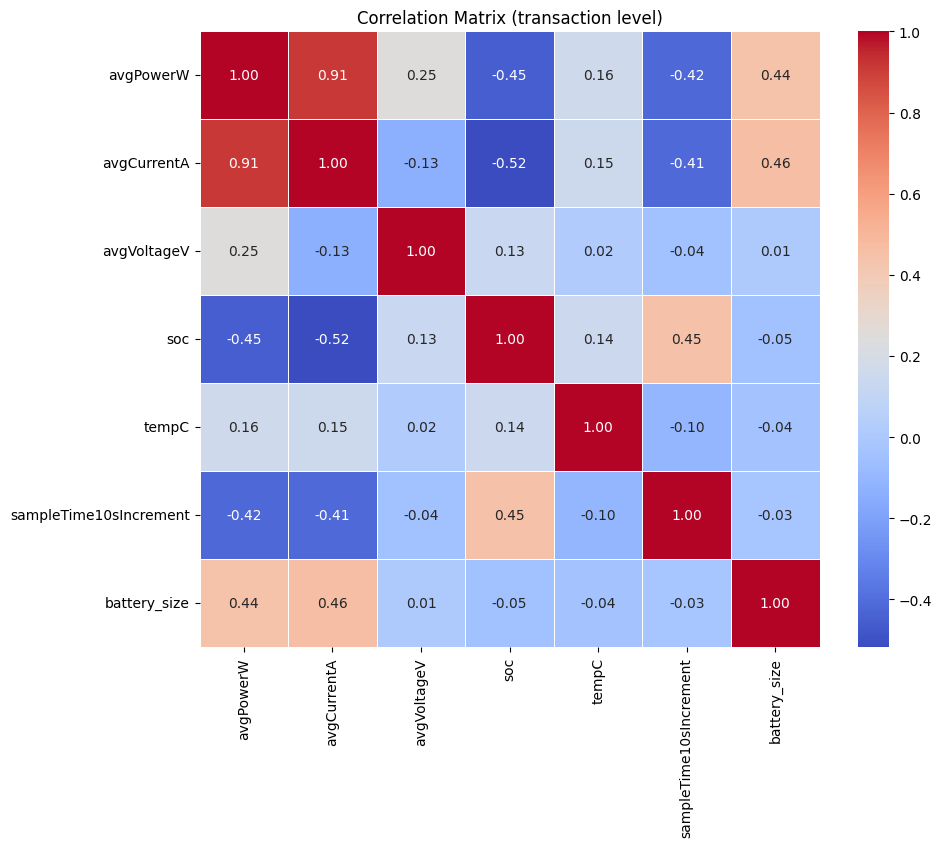

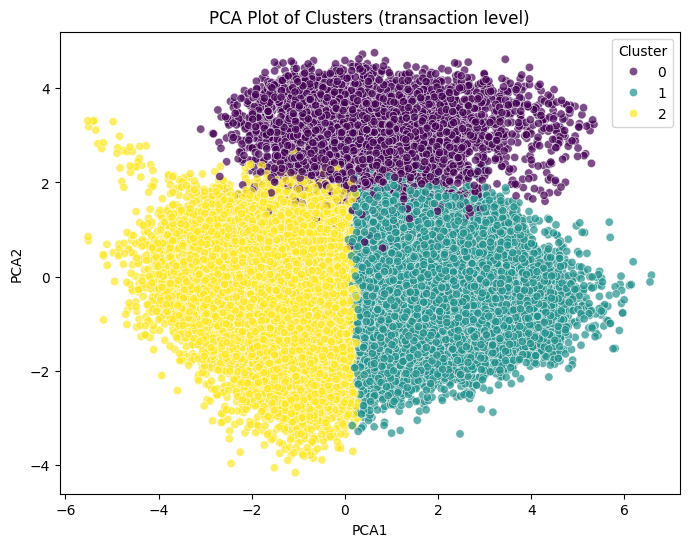


🔹 Silhouette Score (transaction level): 0.272

🔹 Centroids of clusters (in scaled feature space):
   avgPowerW  avgCurrentA  avgVoltageV       soc     tempC  \
0   1.148023    -0.371036     4.086997  0.050910 -0.063530   
1   0.817104     0.965030    -0.267862 -0.620449  0.094293   
2  -0.683177    -0.652384    -0.175293  0.436224 -0.061304   

   sampleTime10sIncrement  battery_size  
0                -0.28684      0.425677  
1                -0.52050      0.499733  
2                 0.39543     -0.393096  

🔹 Assigned SoH Labels based on centroids (heuristic):
   avgPowerW  avgCurrentA  avgVoltageV       soc     tempC  \
0   1.148023    -0.371036     4.086997  0.050910 -0.063530   
1   0.817104     0.965030    -0.267862 -0.620449  0.094293   
2  -0.683177    -0.652384    -0.175293  0.436224 -0.061304   

   sampleTime10sIncrement  battery_size SoH_Label  
0                -0.28684      0.425677     Aging  
1                -0.52050      0.499733  Degraded  
2                 0.3954

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from google.colab import drive

# --- STEP 1: Mount Google Drive ---
drive.mount('/content/drive')

# --- STEP 2: Load Data (e.g. 500k records) ---
file_path = '/content/drive/MyDrive/cryto_research/battery_size/dataset_with_battery_size.csv'
df = pd.read_csv(file_path)

print("\n🔹 Raw Dataset Overview (row level):")
print(df.head())

# --- STEP 3: Aggregate to transaction level (NEW) ---

# We want 1 row per transactionId (i.e., per charging session)
# Choose aggregation logic per column:
# - country, EVModel, weekday, year, month, quarter, battery_size: first (assumed constant in a session)
# - avgPowerW, avgCurrentA, avgVoltageV, soc, tempC: mean over the transaction
# - sampleTime10sIncrement: max (proxy for session length / last timestamp)
agg_dict = {
    'country': 'first',
    'EVModel': 'first',
    'year': 'first',
    'month': 'first',
    'quarter': 'first',
    'weekday': 'first',
    'battery_size': 'first',
    'avgPowerW': 'mean',
    'avgCurrentA': 'mean',
    'avgVoltageV': 'mean',
    'soc': 'mean',
    'tempC': 'mean',
    'sampleTime10sIncrement': 'max'
}

df_txn = df.groupby('transactionId', as_index=False).agg(agg_dict)

print("\n🔹 Transaction-level Dataset Overview (1 row per transactionId):")
print(df_txn.head())

# --- STEP 4: EDA on transaction-level data ---

# 4.1: Summary statistics
print("\n🔹 Summary Statistics (transaction level):")
print(df_txn.describe())

# 4.2: Check for missing values
print("\n🔹 Missing Values (transaction level):")
print(df_txn.isnull().sum())

# 4.3: Visualizing distributions of key features (transaction level)
plt.figure(figsize=(12, 8))
sns.histplot(df_txn['avgPowerW'], kde=True, bins=50)
plt.title('Distribution of avgPowerW per transaction')
plt.show()

plt.figure(figsize=(12, 8))
sns.histplot(df_txn['avgCurrentA'], kde=True, bins=50)
plt.title('Distribution of avgCurrentA per transaction')
plt.show()

plt.figure(figsize=(12, 8))
sns.histplot(df_txn['avgVoltageV'], kde=True, bins=50)
plt.title('Distribution of avgVoltageV per transaction')
plt.show()

# 4.4: Correlation Matrix
plt.figure(figsize=(10, 8))
correlation_matrix = df_txn[['avgPowerW', 'avgCurrentA', 'avgVoltageV',
                             'soc', 'tempC', 'sampleTime10sIncrement',
                             'battery_size']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix (transaction level)')
plt.show()

# --- STEP 5: Data Preprocessing ---

# 5.1: Handle missing values (drop rows with missing values for simplicity)
df_txn.dropna(inplace=True)

# 5.2: One-Hot Encoding for categorical variables (if you want to use them later)
df_encoded = pd.get_dummies(df_txn, columns=['country', 'EVModel', 'weekday'], drop_first=True)

# 5.3: Feature Selection for SoH clustering
# NOTE: We keep it similar to your original features, now at transaction level.
features = ['avgPowerW', 'avgCurrentA', 'avgVoltageV',
            'soc', 'tempC', 'sampleTime10sIncrement', 'battery_size']

X = df_encoded[features]

# 5.4: Standardizing the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- STEP 6: Clustering (K-Means) ---

# 6.1: Apply K-Means clustering (3 clusters as in your example)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10, max_iter=300)
df_encoded['Cluster'] = kmeans.fit_predict(X_scaled)

# --- STEP 7: Dimensionality Reduction for Visualization ---

# 7.1: PCA to reduce data to 2D for visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

# 7.2: Create a DataFrame for PCA results
pca_df = pd.DataFrame(data=principal_components, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = df_encoded['Cluster']

# 7.3: Plot the clusters in PCA space
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='Cluster', palette='viridis', alpha=0.7)
plt.title("PCA Plot of Clusters (transaction level)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend(title='Cluster')
plt.show()

# --- STEP 8: Clustering Evaluation ---

silhouette_avg = silhouette_score(X_scaled, df_encoded['Cluster'])
print(f"\n🔹 Silhouette Score (transaction level): {silhouette_avg:.3f}")

# --- STEP 9: Centroids & SoH Labeling ---

print("\n🔹 Centroids of clusters (in scaled feature space):")
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=features)
print(centroids)

# Simple rule-based SoH interpretation (same spirit as your previous code)
soh_labels = []
for i, centroid in centroids.iterrows():
    # NOTE: These are on the standardized scale; this is a heuristic rule
    if centroid['soc'] > 0.8 and centroid['avgPowerW'] > 0.5:
        soh_labels.append('Healthy')
    elif centroid['soc'] > 0.0 and centroid['avgPowerW'] > 0.0:
        soh_labels.append('Aging')
    else:
        soh_labels.append('Degraded')

centroids['SoH_Label'] = soh_labels
print("\n🔹 Assigned SoH Labels based on centroids (heuristic):")
print(centroids)

# Map SoH labels back to each transaction
cluster_to_soh = {i: label for i, label in enumerate(soh_labels)}
df_encoded['SoH_Label'] = df_encoded['Cluster'].map(cluster_to_soh)

# Attach transactionId back if it was dropped during encoding
# (it’s still there in df_txn, and also in df_encoded unless dropped)
final_df = df_encoded[['transactionId', 'Cluster', 'SoH_Label']].copy()

print("\n🔹 Final Transaction-level DataFrame with SoH Labels:")
print(final_df.head())
